# Statistics & Probabilities

### Let's start by importing some useful packages

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import math
import scipy
import scipy.stats as stats

## Introduction

Quoting [Wikipedia](https://en.wikipedia.org/wiki/Statistics):

> Statistics is the discipline that concerns the collection, organization, displaying, analysis, interpretation and presentation of **data**.

Statistics gives the possibility to **quantify** uncertainty 🤔

Statisticians can make **categorical statements** 💪 with assurance of their **level of uncertainty** 👌

### Statistical Work

- **Data Analysis**: gathering, display and summarize data
- **Probability**: laws of chance, in or out of the casino
- **Inference**: drawing statistical conclusions from specific data, using probability


## Descriptive Statistics

- How can we discover **underlying patterns** in a heap of numbers?
- How can we **represent** data in useful ways?
- How can we **summarize** the data?

First step: **gather** some data 🕵️‍♀️


**Experiment**: ask students in a University class to give their **weight** (in pounds).

Male (57)

```
140 145 160 190 155 165 150 190 195 138 160 155 153 145 170 175 175 170 180
135 170 157 130 185 190 155 170 155 215 150 145 155 155 150 155 150 180 160
135 160 130 155 150 148 155 150 140 180 190 145 150 164 140 142 136 123 155
```

Female (35)

```
140 120 130 138 121 116 125 145 150 112 125 130 120 130 131 120 118 125 135
125 118 122 115 102 115 150 110 116 108  95 125 133 110 150 108
```

We can convert this raw data into a **DataFrame**:

In [ ]:
male_df = pd.DataFrame([140, 145, 160, 190, 155, 165, 150, 190, 195, 138, 160, 155, 153, 145, 170, 175, 175, 170, 180, 135, 170, 157, 130, 185, 190, 155, 170, 155, 215, 150, 145, 155, 155, 150, 155, 150, 180, 160, 135, 160, 130, 155, 150, 148, 155, 150, 140, 180, 190, 145, 150, 164, 140, 142, 136, 123, 155],
    columns=['weight'])
male_df['sex'] = 'male'
female_df = pd.DataFrame([140, 120, 130, 138, 121, 116, 125, 145, 150, 112, 125, 130, 120, 130, 131, 120, 118, 125, 135, 125, 118, 122, 115, 102, 115, 150, 110, 116, 108, 95, 125, 133, 110, 150, 108],
    columns=['weight'])
female_df['sex'] = 'female'

weights_df = pd.concat([male_df, female_df], ignore_index=True)
weights_df.sample(5)

,weight,sex
14,170,male
12,153,male
67,125,female
62,116,female
55,123,male


We can now **plot** the data. For every number between `95` and `215`, plot a bar chart counting the number of people for a given weight.

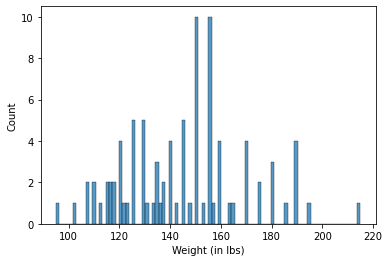

In [ ]:
ax = sns.histplot(weights_df["weight"], bins=len(weights_df))
ax.set_xlabel("Weight (in lbs)")
plt.show()

🤔 What's the name of this graph?

### Histogram

A histogram is an accurate representation of the **distribution** of **numerical** data.

It is an **estimate of the probability distribution** of a continuous variable.

⚠️ Histogram (continuous univariate) ≠ Bar chart (categorical + numerical)

### Histogram Bins

Instead of drawing one bar per integer in $[ 95, 215 ]$, we can create **12** bins and count weights falling into these intervals.

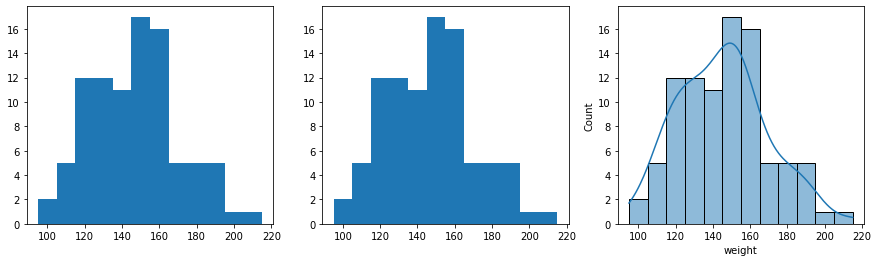

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.hist(weights_df["weight"], bins=[95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 195, 205, 215])
ax2.hist(weights_df["weight"], bins=12)
sns.histplot(weights_df["weight"], bins=12, ax=ax3, kde=True)
plt.show()

## Summary statistics

🎯 Goal: communicate the **largest amount of information** about the distribution of data in the simplest possible way.

Typical summary statistics include measures of:

- Location / central tendency (e.g. **mean**)
- Statistical Dispersion / spread (e.g. **variance**)
- Shape of the distribution (e.g. **skewness** & kurtosis)
- Linear **correlation** of two variables $X$ and $Y$

![image.png](attachment:image.png)

The mean of a **population** of $N$ elements is defined by:

$${\mu} = {\frac {1}{N}}\sum _{i=1}^{N}x_{i}={\frac {x_{1}+x_{2}+\cdots +x_{N}}{N}}$$

The mean of a **sample** of the population $x_1, x_2, ..., x_n$ ($n < N$) is defined by:

$${\bar {x}} = {\frac {1}{n}}\sum _{i=1}^{n}x_{i}={\frac {x_{1}+x_{2}+\cdots +x_{n}}{n}}$$

### Median

The median is the value **separating** the higher half from the lower half of a data sample

**Odd** number of values:

1 3 3 **6** 7 8 9

**Even** number of values

1 2 3 **4 5** 6 8 9

Then median is **4.5**

### Mean vs Median

Median is robust against outliers.

![image.png](attachment:image.png)

### Mode

The mode is the value that appears **most often**

One mode

1 3 6 6 6 6 7 7 12 12 17

The mode is **6** and it is unique.

Bimodal dataset

1 1 2 4 4

There are two modes: **1** and **4**

![image.png](attachment:image.png)

👉 [Skewness](https://en.wikipedia.org/wiki/Skewness) ([_Asymétrie_](https://fr.wikipedia.org/wiki/Asym%C3%A9trie_(statistiques)) 🇫🇷)

### Statistical dispersion

Dispersion (also called variability, scatter, or spread) is the extent to which a distribution is stretched or squeezed.

Examples:

- **Variance** $\sigma^2$
- **Standard deviation** $\sigma$   (_Écart-Type_ 🇫🇷 )
- Interquatile Range $IQR$
- [etc.](https://en.wikipedia.org/wiki/Statistical_dispersion)

The **variance** of a population of $N$ elements is:
$$ {\displaystyle \sigma^2={{\frac {1}{N}}\sum _{i=1}^{N}(x_{i}-{\mu})^{2}}} $$

The **standard deviation** of a **population** of $N$ elements is the square root of the variance:

$$\sigma = {\sqrt {{\frac {1}{N}}\sum _{i=1}^{N}(x_{i}-{\mu})^{2}}}$$

For a **sample** of a population, a good estimator of $\sigma$ is the _sample standard deviation_ :


$$s = \sqrt {{\frac {1}{n-1}}\sum _{i=1}^{n}(x_{i}-{\bar {x}})^{2}}$$

🤔 ${\frac{1}{n}}$ would give an underestimate of the true population variance ([Bessel's correction](https://en.wikipedia.org/wiki/Bessel%27s_correction))

### Interquartile range (IQR)

It's the difference between upper and lower quartiles. $ \text{IQR} = Q_3 - Q_1 $

💡 It can be used to identify outliers in the data set: they are defined as observations that fall below $Q_1$ - 1.5 IQR or above $Q_3$ + 1.5 IQR. 📈 IQR is very useful for **boxplots**!

![image.png](attachment:image.png)

❓ [_But my whiskers are not symmetrical!_](https://stackoverflow.com/questions/51694935/seaborns-boxplot-whiskers-meaning)

### Summary Statistics

Summary statistics of a sample are the five following numbers:

- min
- lower quartile (25%)
- median (50%)
- upper quartile (75%)
- max


$+$ a boxplot

In [ ]:
weights_df['weight'].describe()

count     92.000000
mean     145.152174
std       23.739398
min       95.000000
25%      125.000000
50%      145.000000
75%      155.500000
max      215.000000
Name: weight, dtype: float64

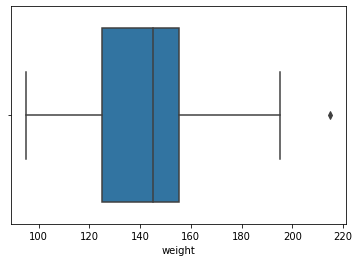

In [ ]:
sns.boxplot(x=weights_df['weight'])
plt.show()

Summary statistics are important, but...

### ⚠️   Beware of the [Datasaurus](https://www.autodeskresearch.com/publications/samestats) 🦕

Summary statistics are not enough, you need to conduct [Exploratory data analysis](https://en.wikipedia.org/wiki/Exploratory_data_analysis) too!

![](https://d2f99xq7vri1nk.cloudfront.net/DinoSequentialSmaller.gif)

### Correlation between 2 variables
The linear correlation between $X$ and $Y$ is also called the [Pearson's coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)

$$r = Corr(X,Y) = {{\frac {\sum \limits _{i=1}^{n}(x_{i}-{\bar {x}})(y_{i}-{\bar {y}})}{n  \sigma_{x} \sigma_{y}}}}$$

![](https://upload.wikimedia.org/wikipedia/commons/thumb/3/34/Correlation_coefficient.png/800px-Correlation_coefficient.png)

![](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/800px-Correlation_examples2.svg.png)

**Correlation vs. Independance?**  
- (X,Y) independant $\Rightarrow $ Corr(X,Y) = 0  
- Corr(X,Y) = 0 $\nRightarrow$ (X,Y) independant (as $r$ only captures **linear** dependance - cf [Wikipedia](https://en.wikipedia.org/wiki/Correlation_and_dependence#Correlation_and_independence))

## Probabilities

### Sets

Probability theory uses the language of sets. A set is a collection of some items (elements).

Example:
    
$$A=\{♣,♢\}$$

You can perform [operations](https://www.probabilitycourse.com/chapter1/1_2_2_set_operations.php) on sets and visualize them with Venn diagrams:

- Union
- Intersection
- Complement
- Substraction
- Partition

### Random experiment

A random experiment is a process by which we observe something uncertain. After the experiment, the result of the random experiment is known: it is the **outcome**.

The set of all possible outcomes is called the **sample space** $S, \Omega \text{ or } U$ (_Univers_ 🇫🇷)

Examples:
    
- Toss a coin. $𝑆=𝐻,𝑇$
- Roll a die. $𝑆=1,2,3,4,5,6$
- Observe the number of goals in a soccer match. $𝑆=0,1,2,3,\ldots$

When we repeat a random experiment several times, we call each one of them a **trial** (épreuve 🇫🇷).

Sample space is defined based on **how you define** the random experiment.

If the experiment is _Toss a coin three times_ then the sample space is:

$$S=\{ (H,H,H),(H,H,T),(H,T,H),(T,H,H),(H,T,T),(T,H,T),(T,T,H),(T,T,T) \}$$

The goal is to assign a **probability** to events, defined as **subsets** of a sample space $S$.

### Union  & Intersection

If $A$ and $B$ are events, then $A \cup B$ (union) and $A \cap B$ (intersection) are events too.

- $\cup$ - Union occurs iif $A$ **or** $B$ occurs
- $\cap$ - Intersection occurs iif $A$ **and** $B$ occur at the same time

### Probability

We assign a probability measure $P(A)$ to an event $A$.

This is a value between 0 and 1 that shows how likely the event is.

Some property you can easily visualize with venn diagrams:

$$P(A^\complement)=1−P(A)$$

$$P(A \cup B)=P(A)+P(B)−P(A \cap B)$$

### Conditional Probability

As you obtain **additional information**, how would you update probabilities of events?

#### Defitinion

Let A and B be two events. By definition:

$$P(A \cap B) = P(A)\cdot P(B\mid A) $$


$P(B\mid A)$ is called the *conditional probability of B given A*, sometimes also noted $P_A(B)$

#### Example

Let's consider the random experiment: draw two cards, one at a time, without replacement, in a deck of 52 cards.

You draw the first card: it's a King (event $A$).

❓ What's the probability that the second card is also a King (event $B$)?

### Solution

The first card is not placed back in the deck which means $A$ and $B$ are **dependant**.

$$P(A) = \frac{4}{52} \approx 0.077$$

$$P(B \mid A) = \frac{3}{51} \approx 0.059$$

$$P(A \cap B) = P(A) \cdot P(B\mid A) = \frac{1}{221} \approx 0.005$$

### Statistical Independence

Events $A$ and $B$ are independant iif:

$$P(A\mid B) = P(A) \ (\text{if} \ P(B) \neq 0)$$

<details>
  <summary>What is statistical dispersion?</summary>

Dispersion (also called variability, scatter, or spread) is the extent to which a distribution is stretched or squeezed.
</details>

### [Bayes' Theorem](https://en.wikipedia.org/wiki/Bayes%27_theorem)

🤔 Suppose we know $P(B \mid A)$ and we want to compute $P(A \mid B)$

We know that, *by definition*

$P(A \cap B) = P(A) \cdot P(B\mid A) \\
P(B \cap A) = P(B) \cdot P(A\mid B)
$

With a simple symmetry argument, we have $ P(A \cap B) = P(B \cap A) $
so...

🔥 **Bayes Theorem**
$$P(A\mid B)={\frac {P(B\mid A) \cdot P(A)}{P(B)}}$$ 

for any two events $A$ and $B$, where $P(B) \neq 0$:

#### Example - Testing a Disease

A disease affects about 1 out of 1000 people.

$$P(Sick) = 0.001$$

There is a test to check whether the person has the disease and we know that:

The probability that the test result is **positive** ($\pmb{+}$) given the person **is sick** is 99% (**true positive**):

$$P(\pmb{+}\mid S_{ick}) = 0.99$$


The probability that the test result is **positive** ($\pmb{+}$) given the person does **is healthy** ($H_{ealthy} = S_{ick}^\complement$) is 2% (**false positive**):

$$P(\pmb{+}\mid H_{ealhy}) = P(\pmb{+}\mid S_{ick}^\complement) = 0.02$$

A random person gets tested for the disease and the result comes back positive 😱.

🤔 What is the probability that the person **actually** has the disease?

$$P(S_{ick} \mid \pmb{+}) = \text{?}$$

Bayes' theorem can be written as:

$$P(S_{ick}\mid \pmb{+})={\frac {P(\pmb{+}\mid S_{ick}) \cdot P(S_{ick})}{P(\pmb{+})}}$$

$$
\begin{align}
P(\pmb{+}) &= P(\pmb{+} \cap S_{ick}) + P(\pmb{+} \cap S_{ick}^\complement)
\end{align}
$$

$$
\begin{align}
P(\pmb{+}) &= P(\pmb{+} \mid S_{ick}) \cdot P(S_{ick}) + P(\pmb{+} \mid H_{ealthy}) \cdot P(H_{ealthy})\\
 &= P(\pmb{+} \mid S_{ick}) \cdot P(S_{ick}) + P(\pmb{+} \mid H_{ealthy}) \cdot (1 - P(S_{ick}))\\
 &= 0.99 \times 0.001 + 0.02 \times (1 - 0.001) \\
 &= 0.02097
\end{align}
$$

We can now compute $P(S_{ick} \mid \pmb{+})$:

$$
\begin{align}
P(S_{ick}\mid \pmb{+}) &={\frac {0.99 \times 0.001}{0.02097}} \\
 &\approx 0.047
\end{align}
$$

💡 Less than 5% of people positively tested with test $\pmb{+}$ actually have the disease. This is called the [**false positive paradox**](https://en.wikipedia.org/wiki/Base_rate_fallacy#False_positive_paradox)

👉 [Bayes Theorem](https://www.youtube.com/watch?v=HZGCoVF3YvM) on Youtube, by 3blue1brown 👌

## Random variable

Statistics ❤️ Probabilities

To analyze random experiments, we focus on some **numerical** aspects of the experiment.

For example, in a soccer game we may be interested in the number of goals, shots, shots on target etc.

If we consider an entire soccer match as a random experiment, then each of these numerical results gives some information about the outcome of the random experiment. These are examples of **random variables**.

### Example of a random experiment

Let's toss a fair coin **twice**.


Sample space is $S = \{ (H, H), (H, T), (T, H), (T, T) \}$

Let's define the random variable $X$ as the **number of heads**.

### Definition

A random variablle $X$ is a function from the sample space to the real numbers:

$$X:S\rightarrow \mathbb{R}$$

The range of a random variable $X$, shown by $Range(X)$, is the set of possible values of $X$.

In our example ($X$ as the **number of heads**):
    
$$Range(X) = \{ 0, 1, 2 \}$$

### Probability Mass Function ([PMF](https://en.wikipedia.org/wiki/Probability_mass_function))

The PMF for $X$ is defined as:

$$\forall x_i \text{ in } Range(X),\ \text{pmf}_{X}(x_i) = P(X = x_i)$$

![image.png](attachment:image.png)

✏️ Let's draw the PMF of $X = $**"Number of Heads"** for the sample space:

$$S = \{ (H, H), (H, T), (T, H), (T, T) \}$$

### [Expected value](https://en.wikipedia.org/wiki/Expected_value)

Intuitively, a random variable's expected value represents the average of a large number of independent realizations of the random variable.

$X$ being a **discrete** random value:

$${\displaystyle \operatorname {E} [X]=\sum _{i=1}^{n }x_{i}\,p(x_i).}$$

### [Bernoulli process](https://en.wikipedia.org/wiki/Bernoulli_process)


A repeated sequence of binary random variables (e.g coin flipping), with a probability $p$ of getting $1$ (e.g. _Heads_)

In [ ]:
np.random.binomial(n=1, p=0.3, size=10)
# size = 10 trials or "coin flips" with a rigged coin (0.3 of heads)
# n=1 repetition of "coin flips"

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
n = 5
np.random.binomial(n=n, p=0.3, size=10) / n # Divide by n to get the mean

array([0.2, 0.4, 0.4, 0. , 0. , 0.4, 0.2, 0.4, 0. , 0.4])

/Users/davywai/.pyenv/versions/3.8.12/envs/lewagon_data_staff/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:>

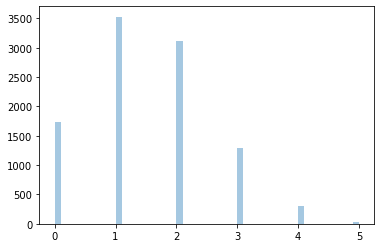

In [ ]:
n = 5
sns.distplot(np.random.binomial(n=n, p=0.3, size=10000), kde=False)

This is called a **Binomial Distribution** $B(n, p)$. Its PMF (Probability Mass Function) is:

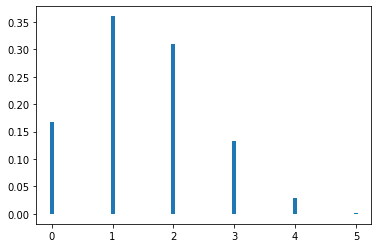

In [ ]:
n = 5
p = 0.3

x = np.arange(n + 1)
pmf = stats.binom.pmf(x, n, p)
plt.vlines(x, 0, pmf, linewidth=4)

As $n$ increases, the mean of Bernouilli processes is **approximated** by a [normal distribution](https://en.wikipedia.org/wiki/Normal_distribution)

<AxesSubplot:ylabel='Density'>

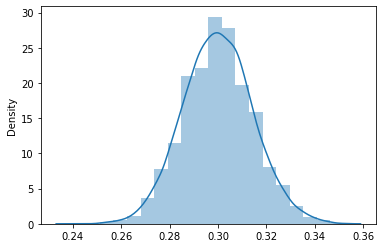

In [ ]:
n = 1000
sns.distplot(np.random.binomial(n=n, p=0.3, size=10000) / n, bins=20)

## Normal Distribution


PDF (Probability Density Function) is:

$${\mathcal N(\mu, \sigma) ={\frac {1}{\sqrt {2\pi \sigma ^{2}}}}e^{-{\frac {(x-\mu )^{2}}{2\sigma ^{2}}}}}$$

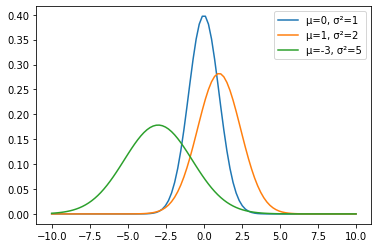

In [ ]:
def plot_normal_distribution(mu, variance):
    sigma = math.sqrt(variance)
    x = np.linspace(-10, 10, 100)
    plt.plot(x, stats.norm.pdf(x, mu, sigma), label=f"μ={mu}, σ²={variance}")

plot_normal_distribution(0, 1)
plot_normal_distribution(1, 2)
plot_normal_distribution(-3, 5)
plt.legend()
plt.show()

<img src="https://upload.wikimedia.org/wikipedia/commons/a/a9/Empirical_Rule.PNG" width=600>

### PDF vs CDF?

![image.png](attachment:image.png)

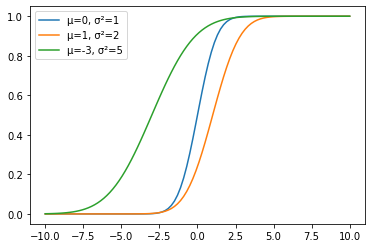

In [ ]:
def plot_cumulative_normal_distribution(mu, variance):
    sigma = math.sqrt(variance)
    x = np.linspace(-10, 10, 100)
    plt.plot(x, stats.norm.cdf(x, mu, sigma), label=f"μ={mu}, σ²={variance}")

plot_cumulative_normal_distribution(0, 1)
plot_cumulative_normal_distribution(1, 2)
plot_cumulative_normal_distribution(-3, 5)
plt.legend()
plt.show()

## [Central Limit Theorem](https://en.wikipedia.org/wiki/Central_limit_theorem)

We will cover the **Central Limit Theorem** and the **Z-score** extensively tonight during the RECAP. Here are the main ideas for future reference:

- We saw that the sum/mean of a **Bernouilli process** converges towards a $\mathcal N$ distribution
- Actually, this holds true for **any** random process!

When **independent** random variables $X_1\dots X_n$ with **common** probability distribution (of mean$\mu$ and std $\sigma$) are **added**:
- Their mean $\overline X$ converges towards a normal distribution as the number of sample $n$ increases
- Centered on the common mean $\mu$
- of standard deviation ${\frac{\sigma}{\sqrt n}}$

This holds true **whatever** the form of the common distribution is

<img width="400" src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/7b/IllustrationCentralTheorem.png/800px-IllustrationCentralTheorem.png" />

[Note to teachers]

The property of the sample mean $\bar X = \mu$ and sample std $\sigma_X = {\frac{\sigma}{\sqrt n}}$ has nothing to do with the CLT and holds true for small $n$ values

$$
\verb|let | Y = {\frac{1}{n}} (X_1+\ldots+X_n)\\
\sigma_X^2 = Var(Y) = ({\frac{1}{n}})^2 Var(X_1+\ldots+X_n) \verb| # property of variance| \\
= {\frac{1}{n^2}} (Var(X_1) +\ldots+ Var(X_n)) \verb| # independence of X's| \\
= {\frac{\sigma}{n}} \verb| # all X's having same variance|
$$



### [Z-score](https://en.wikipedia.org/wiki/Standard_score)

If $x$ is an observation derived from a random variable $X(\mu,\sigma)$

$$z={x-\mu  \over \sigma }$$

z = value of $x$ expressed in **number of std above/below the mean**

Then CLT can be re-written as:

$${\textstyle Z=\left({\frac {{\overline{X}}-\mu }{\sigma /\surd n}}\right)}\to \mathcal N(0,1) \ \text{as } n\to \infty $$  


## Cheat Sheet

**Summary statistics**  
· Mean $\mu$, Median, Mode  
· Standard deviation $\sigma$, Variance $\sigma^2$, IQR  
· Correlation $r = Corr(X,Y)$

**Probability**  
· Conditional probability $P(B|A)$  
· Independence $P(B|A) = P(B)$  
· Bayes Theorem $P(B|A) = P(A|B) {\frac {P(B)}{P(A)}}$  
    
**Random variables** $X$ (numerical outcome of a random experiment)  
**Random process** (repeated sequence of random variable trials)

**Distribution of probability**  
· Binomial $\mathcal B(n, p)$ from Bernouilli (0/1) processes  
· Normal $\mathcal N(\mu, \sigma^2)$ from sum of [idd random variables](https://en.wikipedia.org/wiki/Independent_and_identically_distributed_random_variables)

**Central Limit Theorem**  
· $\ \overline{X} = {\frac{X_1+...+X_n}{n}} \xrightarrow[n \to \infty]{} \mathcal N(\mu,{(\frac{\sigma}{\surd n})^2}) \ $  
· ${\ \textstyle Z=\left({\frac {{\overline{X}}-\mu }{\sigma /\surd n}}\right)} \xrightarrow[n \to \infty]{} \mathcal N(0,1) \ $

## Going Further

Statistics:

- [Sensitivity & Specificity](https://en.wikipedia.org/wiki/Sensitivity_and_specificity)
- [Central Limit Theorem](https://en.wikipedia.org/wiki/Central_limit_theorem)
- [Skew and Kurtosis](https://codeburst.io/2-important-statistics-terms-you-need-to-know-in-data-science-skewness-and-kurtosis-388fef94eeaa)
- [Sampling & Statistical Inference](https://www.probabilitycourse.com/chapter8/8_1_0_intro.php)
- [Confidence Interval](https://en.wikipedia.org/wiki/Confidence_interval)
- [Simpsons' Paradox](https://en.wikipedia.org/wiki/Simpson%27s_paradox)
- https://en.wikipedia.org/wiki/Bootstrapping_(statistics)

Probabilities

- [Probability Mass & Density Functions](https://hadrienj.github.io/posts/Probability-Mass-and-Density-Functions/)  (Hadrien Jean 🙌)
- [Marginal & Conditional Probabilities](https://hadrienj.github.io/posts/Marginal-and-Conditional-Probability/) (🙌)
- 📺 [3Blue1Brown - Bayes Theorem - Inutuitive understanding](https://www.youtube.com/watch?v=HZGCoVF3YvM)

## Your turn!